# **Monte Carlo Pricing of an Asian Option**
The price of an Asian call option is given by:
$$
π_0^{call}= 𝔼[e^{-rT} (\frac{1}{T} ∫_0^T S_u du -K )_+ ]
$$
while the price of an asian put option is
$$
π_0^{put}= 𝔼[e^{-rT} (K - \frac{1}{T} ∫_0^T S_u du)_+ ]
$$
Since the quantity $\frac{1}{T} ∫_0^T S_u du$ does not admit a closed-form expression, it is possible to approximate the option price using Monte Carlo method:
$$
π_0^{call}= \frac{1}{N} \sum_{j=1}^N e^{-rT} ( \frac{1}{n}\sum_{i=1}^n S_{t_i}^{(j)} -K )_+
$$


Black-Scholes model dynamics are assumed, i.e. the underlying asset price follows a geometric Brownian motion, so that the log-returns are normally distributed.

To estimate the option price, N sample paths of underlying asset price $(S_0, ... , S_{t_n})$ are first simulated, obtaining a matrix of size (N,n+1). Then, it is possibile compute the Monte Carlo approximation.

The procedure is implemented in the following steps.

In [37]:
import numpy as np
import matplotlib.pyplot as plt

1. Generate a matrix of normal standard random variable with size (N,n).

In [38]:
def std_normal_matrix(N,n):
  return np.random.randn(N,n)

2. Compute the matrix of $log( \frac {S_{t_{i+1}}} {S_{t_i}})$ with size (N,n).

In [39]:
def log_increment_matrix(sigma, r, T, N, n):
  itv=T/n
  Z=std_normal_matrix(N,n)
  return (r-0.5* sigma**2)*itv+sigma*np.sqrt(itv)*Z

3. Concatenate the vector $log(S_0)$ of size (N,1) with the matrix $log( \frac {S_{t_{i+1}}} {S_{t_i}})$.

In [40]:
def full_log_matrix(S_0, sigma, r, T, N, n):
  log_increments=log_increment_matrix(sigma, r, T, N, n)
  log_S0=np.full((N,1), np.log(S_0))
  return np.concatenate([log_S0,log_increments], axis=1)

4. Compute the underlying price taking the cumulative sum and then the exponential.

In [41]:
def price_matrix(S_0, sigma, r, T, N, n):
  log_increments=full_log_matrix(S_0, sigma, r, T, N, n)
  log_price=np.cumsum(log_increments, axis=1)
  return np.exp(log_price)

5. Compute the Reimann sum for each copy and approximate the price with Monte Carlo method.

In [42]:
def asian_option_price(S_0, K, sigma, r, T, N, n, option_type="call"):
  S=price_matrix(S_0, sigma, r, T, N, n)
  avg_price=np.mean(S[:,1:], axis=1)

  if option_type=="call":
    payoff=np.maximum(avg_price-K,0)
  elif option_type=="put":
    payoff=np.maximum(K-avg_price,0)
  else:
    raise ValueError("option_type should be 'call' or 'put'")
  discounted_payoff=np.exp(-r*T)*payoff

  mc_price=np.mean(discounted_payoff)
  std_error=np.std(discounted_payoff, ddof=1)/np.sqrt(N)
  ci_low=mc_price-1.96*std_error
  ci_high=mc_price+1.96*std_error
  return mc_price, std_error, (ci_low, ci_high)

**Numerical example:** Asian put pricing

In [43]:
S_0=100
K=100
sigma=0.2
r=0.02
T=2
N=100000
n=500

In [44]:
asian=asian_option_price(S_0,K,sigma, r,T,N,n, option_type="put")
print("Asian option price:", asian[0])
print("Standard error:", asian[1])
print("Confidence Interval (95%):", asian[2])

Asian option price: 5.435196420213585
Standard error: 0.02440573052339441
Confidence Interval (95%): (np.float64(5.387361188387732), np.float64(5.483031652039438))


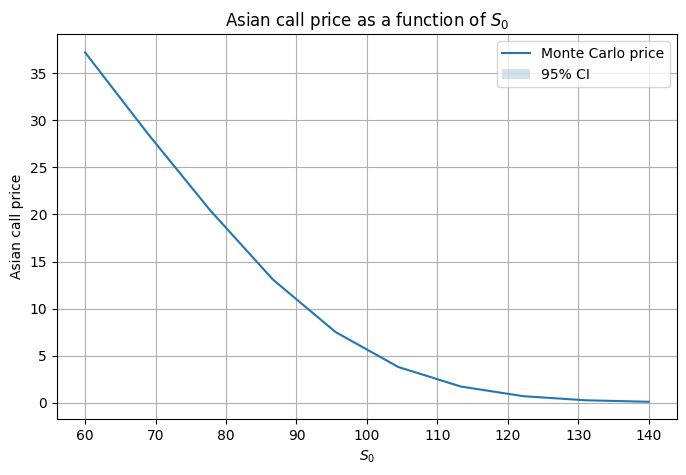

In [46]:
S_0_grid = np.linspace(60, 140, 10)

prices = []
ci_lows = []
ci_highs = []

for s0 in S_0_grid:
    mc_price, std_error, ci = asian_option_price(s0, K, sigma, r, T, N, n, option_type="put")
    prices.append(mc_price)
    ci_lows.append(ci[0])
    ci_highs.append(ci[1])

plt.figure(figsize=(8,5))
plt.plot(S_0_grid, prices, label='Monte Carlo price')
plt.fill_between(S_0_grid, ci_lows, ci_highs, alpha=0.2, label='95% CI')
plt.xlabel("$S_0$")
plt.ylabel("Asian put price")
plt.title("Asian put price as a function of $S_0$")
plt.grid(True)
plt.legend()
plt.show()